In [14]:
import random
import time
import matplotlib.pyplot as plt
import heapq
from collections import defaultdict

## Bài 1:

### **2. Bài toán xếp balo**

In [ ]:
def greedy_knapsack(value, weight, capacity):
  n = len(value)
  fraction = []
  for v in value:
    for w in weight:
      fraction = v / w
  fraction.sort(reverse=True)
  sum = 0
  for i in range(n):
    if (capacity >= weight[i]):
      x[i] = (int)

### **1. Bài toán đổi tiền (Change Coins)**

In [ ]:
def change_money(value_of_money, cash):
  quantity = [0] * len(value_of_money)
  value_of_money.sort(reverse=True)
  remaining_cash = cash
  # current_sum = 0
  result = []
  for i in range(len(value_of_money)):

    if remaining_cash >= value_of_money[i]:
      quantity[i] = remaining_cash // value_of_money[i]
      remaining_cash -= value_of_money[i] * quantity[i]
  if remaining_cash == 0:
    return quantity
  else:
      print(f"Không thể đổi hết {cash} với các mệnh giá cho trước.")
      return None



In [ ]:
value_of_money = [1, 5, 10, 20]  # Các mệnh giá tiền
cash = 67                        # Số tiền cần đổi

print(f"Đổi tiền {cash} bằng các mệnh giá {value_of_money}:")
result = change_money(value_of_money, cash)
if result:
    for i in range(len(value_of_money)):
        if result[i] > 0:
            print(f"Mệnh giá {value_of_money[i]}: {result[i]} tờ")
    print(f"Tổng số tờ: {sum(result)}")

Đổi tiền 67 bằng các mệnh giá [1, 5, 10, 20]:
Mệnh giá 20: 3 tờ
Mệnh giá 5: 1 tờ
Mệnh giá 1: 2 tờ
Tổng số tờ: 6


In [ ]:
# def kruskal_tree(graph,vertex, edge):


### **3. Bài toán lập lịch sử dụng tài nguyên (Activity Selection/Task Scheduling)**

In [2]:
def activity_selection(start_times, finish_times):
    n = len(start_times)
    # Sắp xếp các hoạt động theo thời gian kết thúc
    activities = list(zip(start_times, finish_times))
    activities.sort(key=lambda x: x[1])  # Sắp xếp theo finish time

    # Chọn hoạt động đầu tiên
    selected = [0]  # Lưu index của các hoạt động được chọn
    last_finish = activities[0][1]

    # Duyệt qua các hoạt động còn lại
    for i in range(1, n):
        if activities[i][0] >= last_finish:
            selected.append(i)
            last_finish = activities[i][1]

    return selected

Thời gian bắt đầu: [1, 3, 0, 5, 3, 5, 6, 8, 8, 2, 12]
Thời gian kết thúc: [4, 5, 6, 7, 9, 9, 10, 11, 12, 14, 16]
Các hoạt động được chọn (index): [0, 3, 7, 10]
Số hoạt động tối đa: 4
Kích thước 100: 0.0527 ms
Kích thước 500: 0.2391 ms
Kích thước 1000: 0.4690 ms
Kích thước 5000: 4.0512 ms
Kích thước 10000: 8.0612 ms


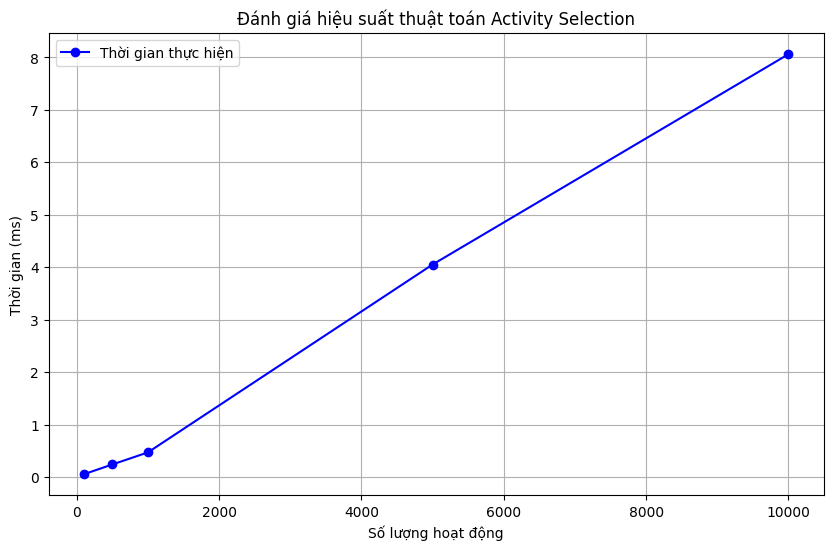

In [4]:
def generate_random_activities(n):
    start_times = []
    finish_times = []
    for _ in range(n):
        start = random.randint(0, 20)
        finish = start + random.randint(1, 10)
        start_times.append(start)
        finish_times.append(finish)
    return start_times, finish_times


def measure_time(n):
    start_times, finish_times = generate_random_activities(n)
    start_time = time.time()
    activity_selection(start_times, finish_times)
    end_time = time.time()
    return (end_time - start_time) * 1000

def main():
    start_times = [1, 3, 0, 5, 3, 5, 6, 8, 8, 2, 12]
    finish_times = [4, 5, 6, 7, 9, 9, 10, 11, 12, 14, 16]
    selected = activity_selection(start_times, finish_times)
    print("Thời gian bắt đầu:", start_times)
    print("Thời gian kết thúc:", finish_times)
    print("Các hoạt động được chọn (index):", selected)
    print("Số hoạt động tối đa:", len(selected))

    sizes = [100, 500, 1000, 5000, 10000]
    times = []

    for size in sizes:
        execution_time = measure_time(size)
        times.append(execution_time)
        print(f"Kích thước {size}: {execution_time:.4f} ms")


    plt.figure(figsize=(10, 6))
    plt.plot(sizes, times, 'bo-', label='Thời gian thực hiện')
    plt.xlabel('Số lượng hoạt động')
    plt.ylabel('Thời gian (ms)')
    plt.title('Đánh giá hiệu suất thuật toán Activity Selection')
    plt.grid(True)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()

### **4. Thuật toán Prim tìm cây bao trùm tối thiểu (Minimal Spanning Tree).**

In [5]:
def prim(graph):
    n = len(graph)
    visited = [False] * n
    min_heap = []  # Hàng đợi ưu tiên lưu các cạnh
    mst_weight = 0
    mst_edges = []

    # Bắt đầu từ đỉnh 0
    visited[0] = True
    for v, weight in enumerate(graph[0]):
        if weight != 0:  # Chỉ thêm các cạnh có trọng số khác 0
            heapq.heappush(min_heap, (weight, 0, v))

    # Chạy thuật toán Prim
    while min_heap:
        weight, u, v = heapq.heappop(min_heap)
        if visited[v]:
            continue

        visited[v] = True
        mst_weight += weight
        mst_edges.append((u, v, weight))

        # Thêm các cạnh kề của đỉnh v vào hàng đợi
        for next_v, w in enumerate(graph[v]):
            if not visited[next_v] and w != 0:
                heapq.heappush(min_heap, (w, v, next_v))

    return mst_weight, mst_edges

Ví dụ minh họa:
Tổng trọng số MST: 37
Các cạnh trong MST: [(0, 1, 4), (0, 7, 8), (7, 6, 1), (6, 5, 2), (5, 2, 4), (2, 8, 2), (2, 3, 7), (3, 4, 9)]
Kích thước 10 đỉnh: 0.0231 ms
Kích thước 50 đỉnh: 0.7582 ms
Kích thước 100 đỉnh: 6.9711 ms
Kích thước 200 đỉnh: 19.0694 ms
Kích thước 500 đỉnh: 246.5441 ms


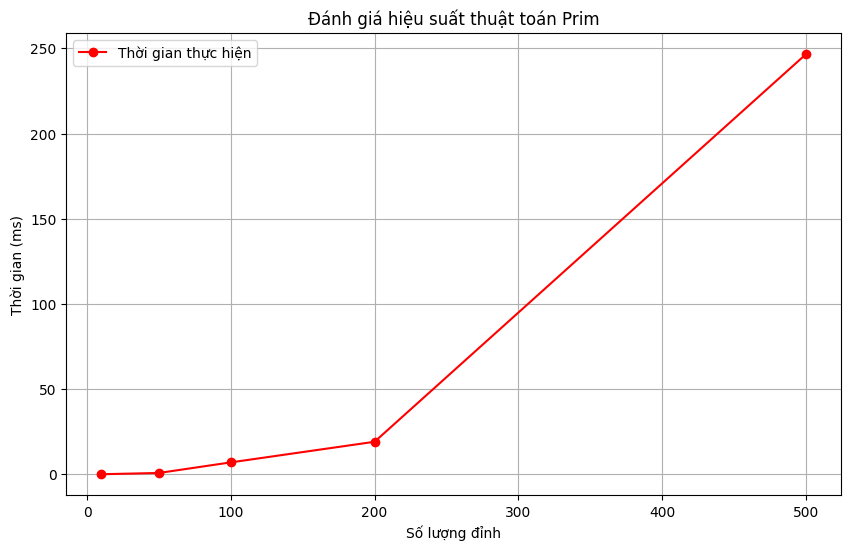

In [8]:
def generate_random_graph(n):
    graph = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            # Tạo cạnh ngẫu nhiên với xác suất 70%
            if random.random() < 0.7:
                weight = random.randint(1, 100)
                graph[i][j] = weight
                graph[j][i] = weight  # Đồ thị vô hướng
    return graph
def measure_time(n):
    graph = generate_random_graph(n)
    start_time = time.time()
    prim(graph)
    end_time = time.time()
    return (end_time - start_time) * 1000


def main():
    graph = [
        [0, 4, 0, 0, 0, 0, 0, 8, 0],
        [4, 0, 8, 0, 0, 0, 0, 11, 0],
        [0, 8, 0, 7, 0, 4, 0, 0, 2],
        [0, 0, 7, 0, 9, 14, 0, 0, 0],
        [0, 0, 0, 9, 0, 10, 0, 0, 0],
        [0, 0, 4, 14, 10, 0, 2, 0, 0],
        [0, 0, 0, 0, 0, 2, 0, 1, 6],
        [8, 11, 0, 0, 0, 0, 1, 0, 7],
        [0, 0, 2, 0, 0, 0, 6, 7, 0]
    ]
    mst_weight, mst_edges = prim(graph)
    print("Tổng trọng số MST:", mst_weight)
    print("Các cạnh trong MST:", mst_edges)

    # Đo thời gian thực hiện với các kích thước khác nhau
    sizes = [10, 50, 100, 200, 500]
    times = []

    for size in sizes:
        execution_time = measure_time(size)
        times.append(execution_time)
        print(f"Kích thước {size} đỉnh: {execution_time:.4f} ms")

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, times, 'ro-', label='Thời gian thực hiện')
    plt.xlabel('Số lượng đỉnh')
    plt.ylabel('Thời gian (ms)')
    plt.title('Đánh giá hiệu suất thuật toán Prim')
    plt.grid(True)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()

### **5. Thuật toán Kruskal tìm cây bao trùm tối thiểu (Minimal Spanning Tree)**

In [9]:
class DisjointSet:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, u):
        if self.parent[u] != u:
            self.parent[u] = self.find(self.parent[u])  # Path compression
        return self.parent[u]

    def union(self, u, v):
        pu, pv = self.find(u), self.find(v)
        if pu == pv:
            return False
        if self.rank[pu] < self.rank[pv]:
            pu, pv = pv, pu
        self.parent[pv] = pu
        if self.rank[pu] == self.rank[pv]:
            self.rank[pu] += 1
        return True

In [10]:
def kruskal(graph):
    n = len(graph)
    edges = []
    # Tạo danh sách cạnh từ ma trận kề
    for i in range(n):
        for j in range(i + 1, n):
            if graph[i][j] != 0:
                edges.append((graph[i][j], i, j))

    # Sắp xếp các cạnh theo trọng số
    edges.sort()

    ds = DisjointSet(n)
    mst_weight = 0
    mst_edges = []

    # Chọn các cạnh cho MST
    for weight, u, v in edges:
        if ds.union(u, v):
            mst_weight += weight
            mst_edges.append((u, v, weight))

    return mst_weight, mst_edges

Tổng trọng số MST: 37
Các cạnh trong MST: [(6, 7, 1), (2, 8, 2), (5, 6, 2), (0, 1, 4), (2, 5, 4), (2, 3, 7), (0, 7, 8), (3, 4, 9)]
Kích thước 10 đỉnh: 0.0608 ms
Kích thước 50 đỉnh: 1.1854 ms
Kích thước 100 đỉnh: 4.1556 ms
Kích thước 200 đỉnh: 16.4876 ms
Kích thước 500 đỉnh: 163.3241 ms


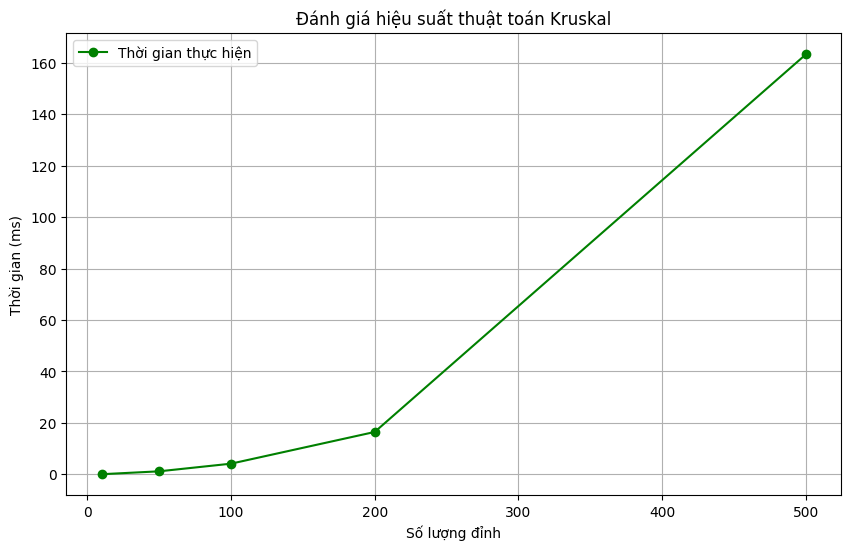

In [11]:
def generate_random_graph(n):
    graph = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            # Tạo cạnh ngẫu nhiên với xác suất 70%
            if random.random() < 0.7:
                weight = random.randint(1, 100)
                graph[i][j] = weight
                graph[j][i] = weight  # Đồ thị vô hướng
    return graph

# Hàm đo thời gian thực hiện
def measure_time(n):
    graph = generate_random_graph(n)
    start_time = time.time()
    kruskal(graph)
    end_time = time.time()
    return (end_time - start_time) * 1000

def main():
    graph = [
        [0, 4, 0, 0, 0, 0, 0, 8, 0],
        [4, 0, 8, 0, 0, 0, 0, 11, 0],
        [0, 8, 0, 7, 0, 4, 0, 0, 2],
        [0, 0, 7, 0, 9, 14, 0, 0, 0],
        [0, 0, 0, 9, 0, 10, 0, 0, 0],
        [0, 0, 4, 14, 10, 0, 2, 0, 0],
        [0, 0, 0, 0, 0, 2, 0, 1, 6],
        [8, 11, 0, 0, 0, 0, 1, 0, 7],
        [0, 0, 2, 0, 0, 0, 6, 7, 0]
    ]
    mst_weight, mst_edges = kruskal(graph)
    print("Tổng trọng số MST:", mst_weight)
    print("Các cạnh trong MST:", mst_edges)

    sizes = [10, 50, 100, 200, 500]
    times = []

    for size in sizes:
        execution_time = measure_time(size)
        times.append(execution_time)
        print(f"Kích thước {size} đỉnh: {execution_time:.4f} ms")

    plt.figure(figsize=(10, 6))
    plt.plot(sizes, times, 'go-', label='Thời gian thực hiện')
    plt.xlabel('Số lượng đỉnh')
    plt.ylabel('Thời gian (ms)')
    plt.title('Đánh giá hiệu suất thuật toán Kruskal')
    plt.grid(True)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()

### **6. Thuật toán Dijkstra.**

In [12]:
def dijkstra(graph, source):
    n = len(graph)
    distances = [float('inf')] * n  # Khoảng cách từ nguồn đến các đỉnh
    distances[source] = 0
    pq = [(0, source)]  # Hàng đợi ưu tiên: (khoảng cách, đỉnh)
    visited = [False] * n

    while pq:
        dist, u = heapq.heappop(pq)
        if visited[u]:
            continue

        visited[u] = True
        # Cập nhật khoảng cách đến các đỉnh kề
        for v, weight in enumerate(graph[u]):
            if weight != 0 and not visited[v]:
                new_dist = dist + weight
                if new_dist < distances[v]:
                    distances[v] = new_dist
                    heapq.heappush(pq, (new_dist, v))

    return distances

Khoảng cách từ đỉnh 0 đến các đỉnh khác:
Đỉnh 0: 0
Đỉnh 1: 4
Đỉnh 2: 12
Đỉnh 3: 19
Đỉnh 4: 21
Đỉnh 5: 11
Đỉnh 6: 9
Đỉnh 7: 8
Đỉnh 8: 14
Kích thước 10 đỉnh: 0.0222 ms
Kích thước 50 đỉnh: 0.2348 ms
Kích thước 100 đỉnh: 1.7176 ms
Kích thước 200 đỉnh: 4.1621 ms
Kích thước 500 đỉnh: 20.4716 ms


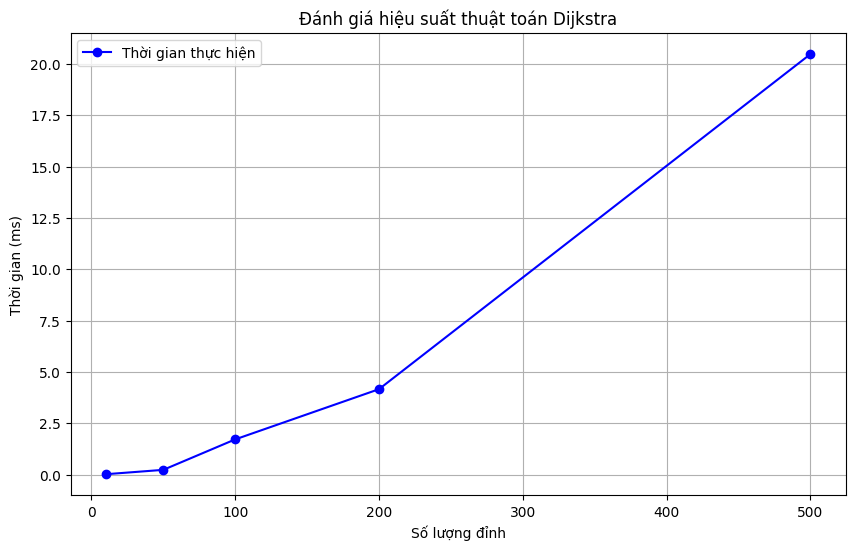

In [13]:
def generate_random_graph(n):
    graph = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            # Tạo cạnh ngẫu nhiên với xác suất 70%
            if random.random() < 0.7:
                weight = random.randint(1, 100)
                graph[i][j] = weight
                graph[j][i] = weight  # Đồ thị vô hướng
    return graph

# Hàm đo thời gian thực hiện
def measure_time(n):
    graph = generate_random_graph(n)
    source = 0  # Chọn đỉnh nguồn là 0
    start_time = time.time()
    dijkstra(graph, source)
    end_time = time.time()
    return (end_time - start_time) * 1000


def main():
    graph = [
        [0, 4, 0, 0, 0, 0, 0, 8, 0],
        [4, 0, 8, 0, 0, 0, 0, 11, 0],
        [0, 8, 0, 7, 0, 4, 0, 0, 2],
        [0, 0, 7, 0, 9, 14, 0, 0, 0],
        [0, 0, 0, 9, 0, 10, 0, 0, 0],
        [0, 0, 4, 14, 10, 0, 2, 0, 0],
        [0, 0, 0, 0, 0, 2, 0, 1, 6],
        [8, 11, 0, 0, 0, 0, 1, 0, 7],
        [0, 0, 2, 0, 0, 0, 6, 7, 0]
    ]
    source = 0
    distances = dijkstra(graph, source)
    print(f"Khoảng cách từ đỉnh {source} đến các đỉnh khác:")
    for i, dist in enumerate(distances):
        print(f"Đỉnh {i}: {dist if dist != float('inf') else '∞'}")

    sizes = [10, 50, 100, 200, 500]
    times = []

    for size in sizes:
        execution_time = measure_time(size)
        times.append(execution_time)
        print(f"Kích thước {size} đỉnh: {execution_time:.4f} ms")

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, times, 'bo-', label='Thời gian thực hiện')
    plt.xlabel('Số lượng đỉnh')
    plt.ylabel('Thời gian (ms)')
    plt.title('Đánh giá hiệu suất thuật toán Dijkstra')
    plt.grid(True)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()

### **7. Huffman code and tree.**

In [15]:
class Node:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq

In [16]:
def huffman_code(freq_dict):
    # Tạo hàng đợi ưu tiên từ tần suất
    heap = []
    for char, freq in freq_dict.items():
        heapq.heappush(heap, Node(char, freq))

    # Xây dựng cây Huffman
    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        parent = Node(None, left.freq + right.freq)
        parent.left = left
        parent.right = right
        heapq.heappush(heap, parent)

    # Tạo bảng mã Huffman
    huffman_dict = {}
    def generate_codes(node, code=""):
        if node:
            if node.char is not None:
                huffman_dict[node.char] = code if code else "0"
            generate_codes(node.left, code + "0")
            generate_codes(node.right, code + "1")

    root = heap[0] if heap else None
    generate_codes(root)
    return huffman_dict, root

Bảng mã Huffman:
A: 0
C: 100
B: 101
F: 1100
E: 1101
D: 111
Kích thước 10 ký tự: 0.0477 ms
Kích thước 50 ký tự: 0.2241 ms
Kích thước 100 ký tự: 0.5188 ms
Kích thước 200 ký tự: 1.3685 ms
Kích thước 500 ký tự: 3.0308 ms


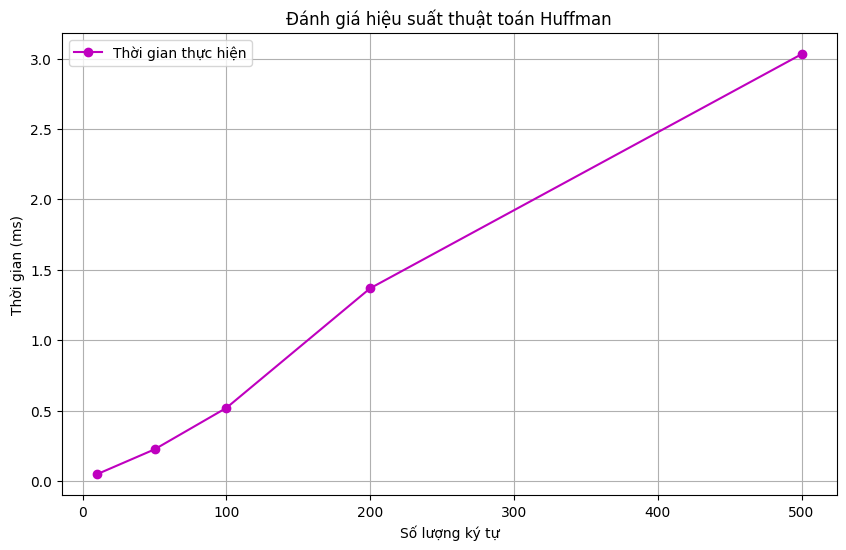

In [17]:
def generate_random_freq(n):
    freq_dict = {}
    for i in range(n):
        char = chr(65 + i)  # Tạo ký tự từ A, B, C,...
        freq = random.randint(1, 100)
        freq_dict[char] = freq
    return freq_dict

def measure_time(n):
    freq_dict = generate_random_freq(n)
    start_time = time.time()
    huffman_code(freq_dict)
    end_time = time.time()
    return (end_time - start_time) * 1000

def main():
    freq_dict = {'A': 45, 'B': 13, 'C': 12, 'D': 16, 'E': 9, 'F': 5}
    codes, root = huffman_code(freq_dict)
    print("Bảng mã Huffman:")
    for char, code in codes.items():
        print(f"{char}: {code}")

    sizes = [10, 50, 100, 200, 500]
    times = []

    for size in sizes:
        execution_time = measure_time(size)
        times.append(execution_time)
        print(f"Kích thước {size} ký tự: {execution_time:.4f} ms")

    plt.figure(figsize=(10, 6))
    plt.plot(sizes, times, 'mo-', label='Thời gian thực hiện')
    plt.xlabel('Số lượng ký tự')
    plt.ylabel('Thời gian (ms)')
    plt.title('Đánh giá hiệu suất thuật toán Huffman')
    plt.grid(True)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()

## Bài 2:

### Exercise 9.1:

#### 9.1.13: How can one use Prim's algorithm to find a spanning tree of a connected graph with no weights on its edges? Is it a good algorithm for this problem?


Thuật toán Prim được thiết kế để tìm **cây bao trùm tối thiểu (Minimum Spanning Tree - MST)** trong một đồ thị có trọng số. Tuy nhiên, nếu đồ thị liên thông không có trọng số trên các cạnh (tức là tất cả các cạnh đều được coi là như nhau), ta vẫn có thể sử dụng Prim để tìm một **cây bao trùm (Spanning Tree)** bất kỳ. Cách thực hiện như sau:

1. **Gán trọng số đồng nhất cho các cạnh:**
- Vì đồ thị không có trọng số, ta có thể gán tất cả các cạnh một trọng số giống nhau, ví dụ như 1 (hoặc bất kỳ giá trị nào, miễn là đồng nhất).
- Khi đó, đồ thị trở thành một đồ thị có trọng số với mọi cạnh đều có trọng số bằng nhau.
2. **Áp dụng thuật toán Prim**:
- Chạy thuật toán Prim như bình thường:
  - Bắt đầu từ một đỉnh bất kỳ.
  - Chọn cạnh có trọng số nhỏ nhất nối tập đỉnh đã thăm với tập đỉnh chưa thăm (vì tất cả trọng số đều bằng nhau, việc chọn cạnh nào cũng được).
  - Lặp lại cho đến khi tất cả các đỉnh được thăm.
- Kết quả là một cây bao trùm, vì Prim đảm bảo tạo ra một cây (không có chu trình) và bao trùm toàn bộ đỉnh của đồ thị liên thông.
3. **Ví dụ**
- Đồ thị: A-B, B-C, C-D, A-D (không trọng số).
- Gán trọng số 1 cho tất cả cạnh: A-B(1), B-C(1), C-D(1), A-D(1).
- Chạy Prim từ A:
  - Chọn A-B (1).
  - Chọn B-C (1).
  - Chọn C-D (1).
  - Kết quả: A-B-C-D (một cây bao trùm).

**Prim có phải là thuật toán tốt cho bài toán này không?**
- Ưu điểm:
  - Prim luôn đảm bảo tạo ra một cây bao trùm nếu đồ thị liên thông.
  - Dễ dàng điều chỉnh bằng cách gán trọng số đồng nhất.
- Nhược điểm:
  - Prim được thiết kế tối ưu cho đồ thị có trọng số khác nhau, nên việc sử dụng nó cho đồ thị không trọng số có thể không tận dụng hết hiệu quả của thuật toán.
  - Có các thuật toán đơn giản hơn như DFS (Depth-First Search) hoặc BFS (Breadth-First Search) cũng có thể tìm cây bao trùm trong đồ thị không trọng số với độ phức tạp thấp hơn:
    - DFS/BFS: O(V + E).
    - Prim (với hàng đợi ưu tiên): O(E log V).
  - Trong trường hợp không cần tối ưu trọng số, Prim có thể xem là "quá mức cần thiết" (overkill).

**Kết luận:** Prim có thể dùng được bằng cách gán trọng số đồng nhất, nhưng không phải là lựa chọn tốt nhất. DFS hoặc BFS sẽ hiệu quả hơn về mặt thời gian và đơn giản hơn để triển khai cho đồ thị không trọng số.

#### 9.1.14. We know Prim's algorithm always yields a minimum spanning tree. Explain the efficiency of Prim's algorithm.

**Độ phức tạp thời gian:**
Hiệu quả của Prim phụ thuộc vào cách triển khai, đặc biệt là cấu trúc dữ liệu được sử dụng:

1. **Triển khai cơ bản (dùng mảng):**
- Tại mỗi bước, tìm cạnh có trọng số nhỏ nhất trong số các cạnh nối từ tập đã thăm đến tập chưa thăm.
- Độ phức tạp:
  - Vòng lặp chính chạy V lần (V là số đỉnh).
  - Mỗi lần tìm cạnh nhỏ nhất tốn O(V) (duyệt qua tất cả đỉnh chưa thăm).
  - Tổng: **O(V²)**.
- Phù hợp với đồ thị dày (nhiều cạnh), nơi E gần với V².

2. **Triển khai với hàng đợi ưu tiên (Priority Queue):**
- Sử dụng min-heap để lưu các cạnh kề từ tập đã thăm.
- Độ phức tạp:
  - Khởi tạo heap: O(V).
  - Mỗi đỉnh được thăm một lần, mỗi lần:
    - Lấy cạnh nhỏ nhất từ heap: O(log V).
    - Cập nhật heap với các cạnh kề: O(E log V) tổng cộng (vì mỗi cạnh được thêm/xóa tối đa một lần).
  - Tổng: **O(E log V)**, với E là số cạnh.
- Phù hợp với đồ thị thưa (ít cạnh).

**Hiệu quả:**
- **Đồ thị thưa (E ≈ V):** O(E log V) gần với O(V log V), rất hiệu quả.
- **Đồ thị dày (E ≈ V²)**: O(E log V) trở thành O(V² log V), kém hơn O(V²) của triển khai cơ bản.
- So với thuật toán Kruskal (O(E log E)):
  - Prim với heap tốt hơn trong đồ thị thưa (E log V thường nhỏ hơn E log E).
  - Kruskal tốt hơn trong đồ thị dày hoặc khi danh sách cạnh đã có sẵn.

**Kết luận:**
- Hiệu quả của Prim phụ thuộc vào cấu trúc dữ liệu:
  - **O(V²)** với mảng: tốt cho đồ thị dày.
  - **O(E log V)** với heap: tốt cho đồ thị thưa.
- Prim rất hiệu quả trong thực tế nhờ tính đơn giản và khả năng triển khai linh hoạt, đặc biệt khi kết hợp với hàng đợi ưu tiên.

### Exercise 9.2:

#### 9.2.5. Design an algorithm for finding a maximum spanning tree—a spanning tree with the largest possible edge weight—of a weighted connected graph.

**Ý tưởng:**
- Kruskal tìm MST bằng cách sắp xếp các cạnh theo trọng số tăng dần và thêm từng cạnh vào cây nếu không tạo chu trình.
- Để tìm cây bao trùm tối đa, ta chỉ cần đảo ngược thứ tự trọng số (tức là sắp xếp giảm dần) hoặc đổi dấu trọng số (nhân với -1) và chạy Kruskal như bình thường.

**Thuật toán:**
1. **Chuyển đổi trọng số:**
- Với mỗi cạnh có trọng số `w`, gán trọng số mới là `-w` (đổi dấu).
- Điều này biến các cạnh có trọng số lớn thành các cạnh có trọng số nhỏ trong đồ thị chuyển đổi.
2. **Áp dụng thuật toán Kruskal:**
- Chạy Kruskal trên đồ thị đã chuyển đổi:
  - Sắp xếp các cạnh theo trọng số tăng dần (trong đồ thị chuyển đổi, cạnh -w lớn sẽ được chọn trước).
  - Sử dụng Disjoint Set để kiểm tra chu trình và thêm cạnh.
- Kết quả là MST của đồ thị chuyển đổi, tương ứng với cây bao trùm tối đa của đồ thị gốc.
3. **Tính tổng trọng số thực tế:**
Lấy danh sách cạnh được chọn và tính tổng trọng số dựa trên giá trị ban đầu (không đổi dấu).

**Mã giả:**
```text
ALGORITHM MaximumSpanningTree(graph)
    // Input: Đồ thị liên thông có trọng số dưới dạng ma trận kề (graph)
    // Output: Tổng trọng số tối đa (maxWeight) và danh sách cạnh của cây bao trùm tối đa (maxEdges)

    // Bước 1: Tạo danh sách cạnh và chuyển đổi trọng số
    edges ← []
    FOR i ← 0 TO n-1 DO
        FOR j ← i+1 TO n-1 DO
            IF graph[i][j] ≠ 0 THEN
                edges ← edges ∪ {(-graph[i][j], i, j)}  // Đổi dấu trọng số
            END IF
        END FOR
    END FOR

    // Bước 2: Sắp xếp các cạnh theo trọng số chuyển đổi tăng dần
    SORT(edges)  // Sắp xếp theo trọng số âm tăng dần (tức trọng số gốc giảm dần)

    // Bước 3: Khởi tạo Disjoint Set và các biến kết quả
    ds ← CREATE_DISJOINT_SET(n)  // n là số đỉnh
    maxWeight ← 0
    maxEdges ← []

    // Bước 4: Chạy Kruskal để tìm cây bao trùm tối đa
    FOR EACH (transWeight, u, v) IN edges DO
        IF ds.FIND(u) ≠ ds.FIND(v) THEN  // Kiểm tra chu trình
            ds.UNION(u, v)               // Hợp nhất hai tập
            originalWeight ← -transWeight // Trọng số ban đầu
            maxWeight ← maxWeight + originalWeight
            maxEdges ← maxEdges ∪ {(u, v, originalWeight)}
        END IF
    END FOR

    // Bước 5: Trả về kết quả
    RETURN maxWeight, maxEdges
END ALGORITHM

// Hàm hỗ trợ Disjoint Set
CREATE_DISJOINT_SET(n)
    parent[0..n-1] ← [0, 1, 2, ..., n-1]  // Mỗi đỉnh là một tập riêng
    rank[0..n-1] ← [0, 0, ..., 0]         // Rank ban đầu là 0
    RETURN {parent, rank}

FIND(u)
    IF parent[u] ≠ u THEN
        parent[u] ← FIND(parent[u])  // Path compression
    END IF
    RETURN parent[u]

UNION(u, v)
    pu ← FIND(u)
    pv ← FIND(v)
    IF pu = pv THEN
        RETURN False
    END IF
    IF rank[pu] < rank[pv] THEN
        SWAP(pu, pv)
    END IF
    parent[pv] ← pu
    IF rank[pu] = rank[pv] THEN
        rank[pu] ← rank[pu] + 1
    END IF
    RETURN True
```


#### 9.2.7. Prove that a graph found in Kruskal’s algorithm is always acyclic.

##### **Chứng minh:**
Ta sẽ chứng minh bằng **quy nạp toán học** dựa trên số cạnh được thêm vào trong quá trình chạy Kruskal.
  
1. **Giả thiết:**
- Gọi F là tập hợp các cạnh được chọn tại bất kỳ thời điểm nào trong Kruskal.
- F là một **rừng (forest)**—tập hợp các cây không giao nhau, mỗi cây không có chu trình.

2.  **Bước cơ sở (Base Case)**
- Khi bắt đầu: F = ∅ (tập rỗng).
- Một đồ thị không có cạnh rõ ràng là **acyclic**.
- Vậy F ban đầu thỏa mãn tính chất không chu trình.

3. **Bước quy nạp (Inductive Step)**
- **Giả sử quy nạp**: Tại bước k, F chứa k cạnh và là một rừng (không có chu trình).
- **Xét bước k+1**: Kruskal chọn cạnh tiếp theo e = (u, v) từ danh sách đã sắp xếp để thêm vào F, với điều kiện không tạo chu trình.
  - Kruskal dùng **Disjoint Set (Union-Find)** để kiểm tra:
    - Nếu FIND(u) = FIND(v) (cùng thành phần liên thông), thêm e sẽ tạo chu trình, nên e bị bỏ qua.
    - Nếu FIND(u) ≠ FIND(v) (khác thành phần), e được thêm vào F, và hai thành phần được hợp nhất bằng UNION(u, v).

- **Trường hợp e được thêm**:
  - u và v thuộc hai cây khác nhau trong F, nên không có đường đi từ u đến v trong F trước khi thêm e.
  - Thêm e nối hai cây thành một cây lớn hơn:
    - Không thể tạo chu trình vì không tồn tại đường đi khác từ v về u trong F.
  - Vậy F ∪ {e} vẫn là một rừng (hoặc một cây nếu đã đủ đỉnh), vẫn **acyclic**.

- **Trường hợp e không được thêm**:
  - F không đổi, nên vẫn giữ tính chất không chu trình.
- **Kết luận bước quy nạp**: Sau bước k+1, F vẫn là một rừng, tức là không có chu trình.

4. **Kết luận quy nạp**
- Với mọi bước thêm cạnh, F luôn là một rừng (acyclic).
- Khi thuật toán kết thúc (sau V-1 cạnh), F trở thành một **cây bao trùm (spanning tree)** — liên thông và không có chu trình.

##### **Kết luận**
Đồ thị được tạo bởi thuật toán Kruskal luôn **không có chu trình (acyclic)** vì:
1. Bắt đầu từ một rừng rỗng (acyclic).
2. Mỗi bước thêm cạnh được kiểm tra kỹ lưỡng để không tạo chu trình thông qua Union-Find.
3. Kết quả cuối cùng là một cây bao trùm, vốn định nghĩa là một đồ thị liên thông không chu trình.

Do đó, tính chất **acyclic** được đảm bảo trong toàn bộ quá trình và kết quả của Kruskal!

### Exercise 9.3:

#### **9.3.6. Give a real life application of Dijkstra's algorithm.**

**Ứng dụng**: Tìm đường đi ngắn nhất trong hệ thống định vị GPS

Thuật toán Dijkstra được sử dụng rộng rãi trong các hệ thống định vị GPS (Global Positioning System) như Google Maps, Apple Maps, hoặc các thiết bị GPS trên ô tô để tìm **đường đi ngắn nhất** từ điểm xuất phát (ví dụ: vị trí hiện tại của bạn) đến điểm đích (địa điểm bạn muốn đến).

**Cách áp dụng**:
1. **Mô hình hóa vấn đề**:
   - Đồ thị: Các nút (vertices) đại diện cho các giao lộ, ngã tư, hoặc địa điểm trên bản đồ. Các cạnh (edges) đại diện cho các đoạn đường nối giữa các nút.
   - Trọng số: Khoảng cách giữa hai nút (tính bằng kilômét hoặc mét) hoặc thời gian di chuyển (tính bằng phút, dựa trên tốc độ trung bình và tình trạng giao thông).

2. **Hoạt động của Dijkstra**:
   - **Đầu vào**: Vị trí xuất phát (nút nguồn) và đích đến (nút đích) trên bản đồ.
   - **Quá trình**: Dijkstra bắt đầu từ nút nguồn, tính toán khoảng cách ngắn nhất đến tất cả các nút khác trong đồ thị, sử dụng hàng đợi ưu tiên để ưu tiên khám phá các nút có khoảng cách nhỏ nhất trước.
   - **Đầu ra**: Đường đi ngắn nhất từ điểm xuất phát đến đích, thường hiển thị dưới dạng danh sách các đoạn đường hoặc hướng dẫn từng bước (ví dụ: "Rẽ trái sau 500m").

3. **Ví dụ thực tế**:
   - Bạn ở Hà Nội (nút A) và muốn đến Hồ Chí Minh (nút B). GPS sử dụng Dijkstra để tính đường đi qua các quốc lộ, tỉnh lộ, dựa trên khoảng cách hoặc thời gian ngắn nhất.
   - Nếu có dữ liệu giao thông thời gian thực (real-time traffic), trọng số có thể thay đổi (ví dụ: đoạn đường tắc nghẽn có thời gian lâu hơn), và Dijkstra sẽ điều chỉnh để tìm đường tối ưu.

**Lợi ích**:
- **Hiệu quả**: Đảm bảo đường đi ngắn nhất (về khoảng cách hoặc thời gian) trong đồ thị có trọng số không âm.
- **Linh hoạt**: Có thể mở rộng để tính thêm các yếu tố như chi phí nhiên liệu, đường thu phí, hoặc ưu tiên đường cao tốc.

**Thực tế mở rộng**:
- Các ứng dụng như Google Maps thường dùng biến thể của Dijkstra (như A* algorithm) để cải thiện tốc độ bằng cách kết hợp heuristic, nhưng nguyên lý cơ bản vẫn dựa trên Dijkstra khi không có thông tin bổ sung.

**Kết luận**:
Thuật toán Dijkstra là nền tảng cho việc tìm đường trong các ứng dụng định vị, giúp hàng triệu người tiết kiệm thời gian và chi phí di chuyển mỗi ngày. Đây là một ví dụ điển hình về cách một thuật toán lý thuyết được áp dụng vào thực tiễn đời sống!